### Builing Chatbot with multiple tools using LangGraph
- arxiv
- wikipedia
- tavily search
- some funtions


In [24]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper


In [25]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [29]:
arxiv.invoke("Attention is all you need")

AttributeError: 'Search' object has no attribute 'results'

In [30]:
from langchain_community.tools import ArxivQueryRun

from langchain_community.utilities import ArxivAPIWrapper

arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

result = arxiv.invoke("Attention is all you need")

print(result[:500])

AttributeError: 'Search' object has no attribute 'results'

In [41]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [42]:
wiki.invoke("Arithmatics")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [2]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY") 


In [44]:
### tavily search tools
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/var/folders/sl/j703510j7nv1c56nnpn57ps40000gn/T/ipykernel_58841/3946675764.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [45]:
tavily.invoke("Provide me recent AI news")

[{'title': 'Google AI announcements from April 2026',
  'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-april-2026',
  'content': '## Bullet points\n\n Check out "The latest AI news we announced in April" for Google\'s newest tech updates.\n Google Cloud introduced powerful new tools and chips to help businesses build AI agents.\n You can now create professional videos for free using the new Google Vids suite.\n New coding tools like Learn Mode in Colab act as your personal programming tutor.\n Google is using AI to improve healthcare access and help students with test prep.\n\n## Basic explainer [...] Learn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\n# The latest AI news we announced in April 2026\n\nMay 04, 2026\n\nHere’s a recap of our biggest AI updates from April, including Gemma 4, Deep Research Max and all the big announcements from Cloud Next ‘26.\n\n## General summary\n\nGoogle’s April updates focused on the

In [63]:
### Combine all the tools in the list

# tools = [arxiv, wiki, tavily]
tools = [wiki, tavily]


In [54]:
### Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)


In [56]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'ft9ayw0t9',
  'type': 'tool_call'}]

In [57]:
### STATE Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

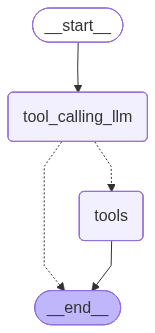

In [61]:
### Entire chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    #
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

#view
display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
messages = graph.invoke({"messages": HumanMessage(content="What is attention all you need")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is attention all you need
================================== Ai Message ==================================
Tool Calls:
  wikipedia (j1fvgefrf)
 Call ID: j1fvgefrf
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: wikipedia

Page: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the 


In [66]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages["messages"]:
    m.pretty_print()

AttributeError: 'Search' object has no attribute 'results'

In [67]:
messages = graph.invoke({"messages": HumanMessage(content="what is 2+2")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2+2
================================== Ai Message ==================================

The sum of 2 and 2 is 4.


In [68]:
messages = graph.invoke({"messages": HumanMessage(content="what is machine learning")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (5mrn20b01)
 Call ID: 5mrn20b01
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me


In [69]:
messages = graph.invoke({"messages": HumanMessage(content="what is current news on Indian Economy")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is current news on Indian Economy
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2esh1m3dr)
 Call ID: 2esh1m3dr
  Args:
    query: recent news on Indian Economy
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Recent Economic News, Latest Indian Economy News | IBEF indian-economy-news", "url": "https://www.ibef.org/indian-economy-news", "content": "India’s emergence as the world’s second-largest solar growth market reflects the rapid expansion of its renewable energy sector and the country’s accelerating transition towards a cleaner and more sustainable energy future.\n\nIndia’s Services Sector Growth Accelerates to Six-Month High in May\n\nStrong growth in business activity, new orders and export demand has propelled India’s services sector to a si